<a href="https://colab.research.google.com/github/ParkHangah/AIFFEL_quest_eng/blob/master/Computer_Vision/CV01/D29_%EA%B3%A0%EC%96%91%EC%9D%B4_%EC%88%98%EC%97%BC_%EC%8A%A4%ED%8B%B0%EC%BB%A4_%EB%A7%8C%EB%93%A4%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **[프로젝트] 고양이 수염 스티커 만들기**

### 체크포인트

* 카메라 스티커앱을 다양한 원본이미지에 적용했을 때의 문제점을 체계적으로 분석하였다.  
→ 얼굴각도, 이미지 밝기, 촬영거리 등 다양한 변수에 따른 영향도를 보고서에 체계적으로 분석하였다.
* 스티커 이미지를 정확한 원본 위치에 반영하였다.  
→ 정확한 좌표계산을 통해 고양이 수염의 위치가 원본 얼굴에 잘 어울리게 출력되었다.
* 자기만의 카메라앱 기능 구현을 완수하였다.  
→ 얼굴 영역과 랜드마크를 정확하게 검출하고, 스티커 사진을 합성시키는 데 성공하였다.

## 0. 사전준비

### 0-1. 구글드라이브 연결

In [ ]:
from google.colab import drive
from IPython.display import clear_output, display
import ipywidgets as widgets
import os

def inf(msg, style, wdth): inf = widgets.Button(description=msg, disabled=True, button_style=style, layout=widgets.Layout(min_width=wdth));display(inf)

print("[0;33mConnecting...")
drive.mount('/content/gdrive')

clear_output()

# Wait for user input and set mainpth
mainpth = os.path.join('/content/gdrive/MyDrive', '#Study/Aiffel/Work')
print(f"Selected Google Drive root path: {mainpth}")

inf('\u2714 Done','success', '50px')

### 0-2. 주요라이브러리 버전 확인

In [2]:
!pip install cmake opencv-python
# !conda install -y dlib

In [3]:
# 코랩은 pip를 통해 라이브러리를 설치하므로 pip로 변경해서 설치 진행
!pip install dlib

In [4]:
# 필요한 패키지 import 하기
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리

# 버전확인
print(cv2.__version__)
print(dlib.__version__)

4.13.0
19.24.6


## Step 1. 스티커 구하기 or 만들기

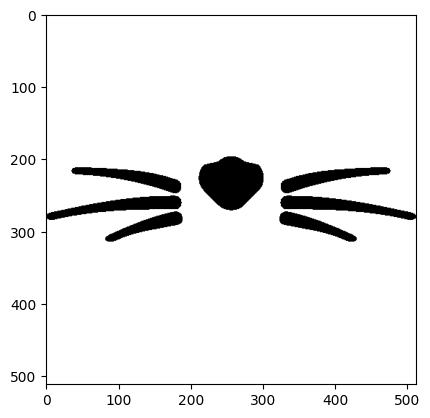

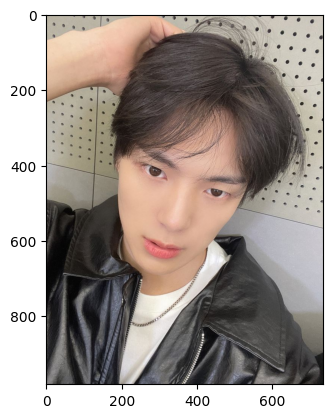

In [19]:
home_dir = os.getenv('HOME')

# 사용할 이미지 불러오기
photo_path = os.path.join(mainpth, 'camera_sticker/images/image_2.jpg') # 본인 이미지가 있는 경로를 가지고 온다.
sticker_path = os.path.join(mainpth, 'camera_sticker/images/cat-whiskers.png') # 고양이 수염 이미지
# OpenCV로 이미지 불러오기 // cv2.imread(이미지 경로) → image객체 행렬을 반환
img_bgr = cv2.imread(photo_path)
img_sticker = cv2.imread(sticker_path)

# 이미지 출력해서 확인해보기 - 스티커
sticker_show = img_sticker.copy()      # 출력용 이미지를 따로 보관합니다
sticker_rgb = cv2.cvtColor(img_sticker, cv2.COLOR_BGR2RGB) #  RGB 이미지로 바꾸기.
plt.imshow(sticker_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

# 이미지 출력해서 확인해보기 - 사진
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) #  RGB 이미지로 바꾸기.
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

## Step 2. 얼굴 검출 & 랜드마크 검출 하기

#### 1) 얼굴 검출

rectangles[[(170, 348) (491, 669)]]


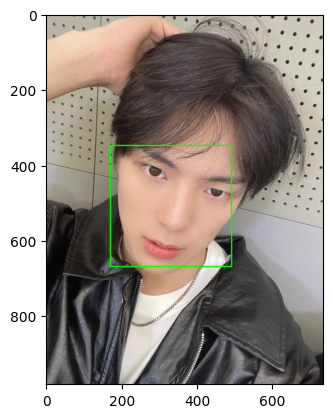

In [20]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)

print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

#### 2) landmark

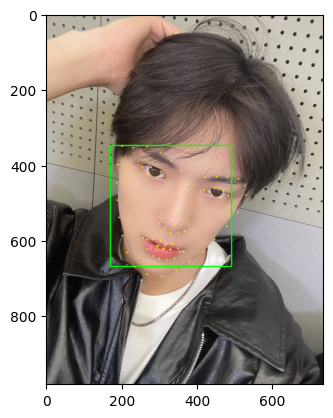

In [21]:
# 저장한 landmark 모델의 주소를 model_path 변수에 저장
model_path = os.path.join(mainpth, 'camera_sticker/models/shape_predictor_68_face_landmarks.dat')
# dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
landmark_predictor = dlib.shape_predictor(model_path)

# 랜드마크의 위치를 저장할 list 생성
list_landmarks = []

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

# face landmark 출력
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)
img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

## Step 3. 스티커 적용 위치 확인하기

### 1) 스티커 위치와 크기 조저을 위한 계산에 필요한 수치 확인

In [8]:
for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    # 수염 붙일 위치와 각도를 계산하기 위해 눈썹 점 위치 불러옴
    print (f"콧등: {landmark[33]}")
    print (f"눈썹 우측: {landmark[21]}")
    print (f"눈썹 좌측: {landmark[22]}")
    x = landmark[33][0]
    y = landmark[33][1]
    x1 = landmark[21][0]
    y1 = landmark[21][1]
    x2 = landmark[22][0]
    y2 = landmark[22][1]
    w = h = dlib_rect.width()
    print (f'(x,y) : ({x},{y})')
    print (f'(x1,y1) : ({x1},{y1})')
    print (f'(x2,y2) : ({x2},{y2})')
    print (f'(w,h) : ({w},{h})')

콧등: (329, 579)
눈썹 우측: (357, 414)
눈썹 좌측: (420, 433)
(x,y) : (329,579)
(x1,y1) : (357,414)
(x2,y2) : (420,433)
(w,h) : (322,322)


### 2) 스티커 크기조정

In [25]:
sticker_path = os.path.join(mainpth, 'camera_sticker/images/cat-whiskers.png') # 고양이 수염 이미지
img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)
img_sticker = cv2.resize(img_sticker, (w,h)) # 스티커 이미지 조정 → w,h는 얼굴 영역의 가로를 차지하는 픽셀의 수(187) // cv2.resize(image객체 행렬, (가로 길이, 세로 길이))
print (img_sticker.shape)

(322, 322, 4)


### 3) 원본에 스티커 이미지를 추가하기 위해 x,y 좌표 계산 및 이미지 자르기


In [26]:
refined_x = x - w // 2
refined_y = y - h // 2 # 고양이 스티커 모양이 위아래 여백이 있기에 가만하여 스티커 높이의 1/2보다 높은 지점부터 붙여야함.
# 음수 발생시 예외 처리
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :] # refined_y가 -98이므로, img_sticker[98: , :]가 된다. (187, 187, 3)에서 (89, 187, 3)이 됨 (187개 중에서 98개가 잘려나감)
    refined_y = 0
print (f'(x,y) : ({refined_x},{refined_y})')

(x,y) : (181,396)


### 4) 스티커 1차 적용

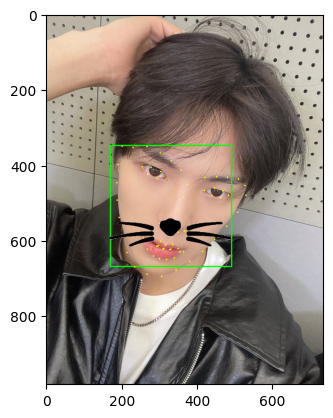

In [11]:
# 1. 스티커 영역 추출 (배경 이미지의 일부)
sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]

# 2. 채널 분리
# img_sticker는 (H, W, 4) -> B, G, R, A
img_sticker_rgb = img_sticker[:, :, :3]  # 앞의 3개 채널 (색상)
alpha_mask = img_sticker[:, :, 3]         # 마지막 4번째 채널 (투명도)

# 3. 마스크를 3차원으로 확장 (H, W) -> (H, W, 1)
# 이렇게 해야 (H, W, 3)인 이미지들과 계산이 가능해집니다.
alpha_mask_3ch = cv2.cvtColor(alpha_mask, cv2.COLOR_GRAY2BGR)

# 4. 투명도 채널을 기준으로 합성
# alpha_mask_3ch가 0보다 큰 곳(불투명)은 스티커 색상을, 0인 곳(투명)은 배경을 사용
img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(alpha_mask_3ch > 0, img_sticker_rgb, sticker_area).astype(np.uint8)

# 결과 확인
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

### 5) 스키터 기울이고 반투명하게 하기

눈썹 기울기를 찾아 그 만큼 수염도 기울어야함.  
두점을 잇는 직선의 기울기 계산  
기울기 $$m = \frac{y_2 - y_1}{x_2 - x_1}$$
각도계산 $$\theta = \arctan(m)$$

In [28]:
import math

def get_slope_and_angle(p1, p2):
    # p1 = (x1, y1), p2 = (x2, y2)
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    # 1. 기울기 구하기 (ZeroDivisionError 방지)
    if dx == 0:
        slope = float('inf')  # 수직선인 경우 무한대
    else:
        slope = dy / dx

    # 2. 각도 구하기 (Radian -> Degree)
    # math.atan2는 (y, x) 순서로 인자를 받습니다.
    radian = math.atan2(dy, dx)
    degree = math.degrees(radian)

    return slope, degree

# 눈썹각도 계산
point_a = (x1, y1)
point_b = (x2, y2)

slope, angle = get_slope_and_angle(point_a, point_b)

print(f"두 점 사이의 기울기: {slope:.2f}")
print(f"두 점 사이의 각도(도): {angle:.2f}°")

두 점 사이의 기울기: 0.30
두 점 사이의 각도(도): 16.78°


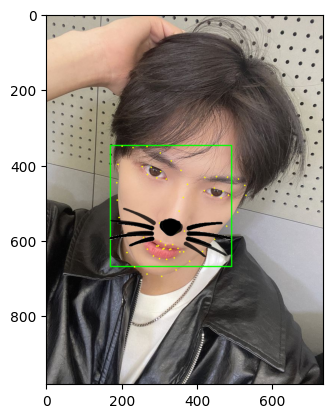

In [13]:
# 1. 설정값
angle = - angle  # 눈썹 사이 기울기
opacity = 0.8  # 투명도 (0.0: 완전 투명, 1.0: 완전 불투명)

# 2. 스티커 읽기 (4채널) 및 크기 조절
img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)
img_sticker = cv2.resize(img_sticker, (w, h))

# 3. 이미지 회전 처리
(h_s, w_s) = img_sticker.shape[:2]
center = (w_s // 2, h_s // 2)

# 회전 행렬 생성 (중심점, 각도, 배율)
# OpenCV는 반시계 방향이 (+)이므로, 시계 방향 회전이 필요하면 -angle을 사용하세요.
matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
img_sticker = cv2.warpAffine(img_sticker, matrix, (w_s, h_s), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0,0))

# 4. 채널 분리 및 투명도 적용
img_sticker_rgb = img_sticker[:, :, :3].astype(float)
alpha_mask = img_sticker[:, :, 3].astype(float) / 255.0  # 0~1 사이로 정규화

# 사용자 설정 투명도 반영
alpha_mask = alpha_mask * opacity

# 5. 배경 영역(sticker_area) 추출
sticker_area = img_show[refined_y:refined_y+h_s, refined_x:refined_x+w_s].astype(float)

# 6. 알파 블렌딩 공식 적용 (부드러운 합성)
# 합성 공식: (스티커 * 알파) + (배경 * (1 - 알파))
for c in range(3): # B, G, R 각 채널에 대해 계산
    sticker_area[:, :, c] = (alpha_mask * img_sticker_rgb[:, :, c] +
                             (1 - alpha_mask) * sticker_area[:, :, c])

# 7. 원본 이미지에 덮어쓰기 (정수형 변환)
img_show[refined_y:refined_y+h_s, refined_x:refined_x+w_s] = sticker_area.astype(np.uint8)

# 결과 출력
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

### 6) 바운딩 박스와 랜드마크 제외하여 다시 출력하기

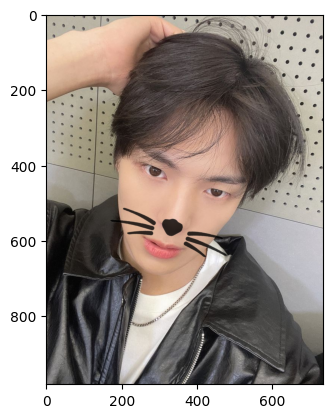

In [14]:
# 위에서 설명했으므로 생략
sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# 합성 공식: (스티커 * 알파) + (배경 * (1 - 알파))
for c in range(3): # B, G, R 각 채널에 대해 계산
    sticker_area[:, :, c] = (alpha_mask * img_sticker_rgb[:, :, c] +
                             (1 - alpha_mask) * sticker_area[:, :, c])

# 원본 이미지에 덮어쓰기 (정수형 변환)
img_bgr[refined_y:refined_y+h_s, refined_x:refined_x+w_s] = sticker_area.astype(np.uint8)

# 결과 출력
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

# 1차 수정

step 1 부터 step 3의 2) 까지는 기존 코드 그대로 사용 (작성 생략)

* 기존 코드를 보면 고양이 코가 너무 아래로 내려와 있음  
⇒ 기존 y - h // 2 는 고양이 코가 스티커 이미지 중심에 있다는 가정하의 설정으로 이를 통한 계산된 y값이 실제 적합한 y값보다 크다는 이야기 (why? 좌표는 좌측 상단에서 시작되니깐! 아래로 갈수록 y 값이 커짐)
* 스티커이미지를 보면 세로 512pixel 크기에서 코가 시작되는 지점이 대략 200에 자리잡아 있음.  
⇒ 따라서 y - h //2 코드를 y - h // 5 *3 으로 바꾸어 봄




In [15]:
refined_x = x - w // 2
refined_y = y - h // 5 * 3 # 고양이 스티커 모양이 위아래 여백이 있기에 가만하여 스티커 높이의 1/2보다 높은 지점부터 붙여야함.
# 음수 발생시 예외 처리
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :] # refined_y가 -98이므로, img_sticker[98: , :]가 된다. (187, 187, 3)에서 (89, 187, 3)이 됨 (187개 중에서 98개가 잘려나감)
    refined_y = 0
print (f'(x,y) : ({refined_x},{refined_y})')

(x,y) : (168,387)


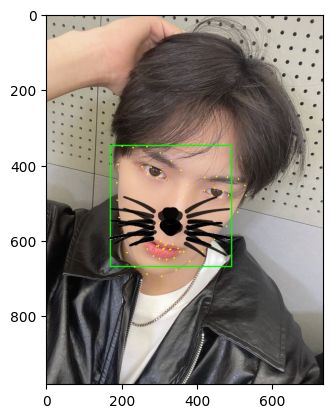

In [17]:
# 1. 설정값
angle = - angle  # 눈썹 사이 기울기
opacity = 0.8  # 투명도 (0.0: 완전 투명, 1.0: 완전 불투명)

# 2. 스티커 읽기 (4채널) 및 크기 조절
img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)
img_sticker = cv2.resize(img_sticker, (w, h))

# 3. 이미지 회전 처리
(h_s, w_s) = img_sticker.shape[:2]
center = (w_s // 2, h_s // 2)

# 회전 행렬 생성 (중심점, 각도, 배율)
# OpenCV는 반시계 방향이 (+)이므로, 시계 방향 회전이 필요하면 -angle을 사용하세요.
matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
img_sticker = cv2.warpAffine(img_sticker, matrix, (w_s, h_s), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0,0))

# 4. 채널 분리 및 투명도 적용
img_sticker_rgb = img_sticker[:, :, :3].astype(float)
alpha_mask = img_sticker[:, :, 3].astype(float) / 255.0  # 0~1 사이로 정규화

# 사용자 설정 투명도 반영
alpha_mask = alpha_mask * opacity

# 5. 배경 영역(sticker_area) 추출
sticker_area = img_show[refined_y:refined_y+h_s, refined_x:refined_x+w_s].astype(float)

# 6. 알파 블렌딩 공식 적용 (부드러운 합성)
# 합성 공식: (스티커 * 알파) + (배경 * (1 - 알파))
for c in range(3): # B, G, R 각 채널에 대해 계산
    sticker_area[:, :, c] = (alpha_mask * img_sticker_rgb[:, :, c] +
                             (1 - alpha_mask) * sticker_area[:, :, c])

# 7. 원본 이미지에 덮어쓰기 (정수형 변환)
img_show[refined_y:refined_y+h_s, refined_x:refined_x+w_s] = sticker_area.astype(np.uint8)

# 결과 출력
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

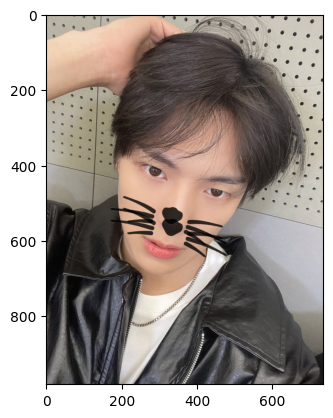

In [18]:
# 위에서 설명했으므로 생략
sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# 합성 공식: (스티커 * 알파) + (배경 * (1 - 알파))
for c in range(3): # B, G, R 각 채널에 대해 계산
    sticker_area[:, :, c] = (alpha_mask * img_sticker_rgb[:, :, c] +
                             (1 - alpha_mask) * sticker_area[:, :, c])

# 원본 이미지에 덮어쓰기 (정수형 변환)
img_bgr[refined_y:refined_y+h_s, refined_x:refined_x+w_s] = sticker_area.astype(np.uint8)

# 결과 출력
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

# 2차 수정

* 이미지 y 위치를 새로 찾는 방식으로 하니, x축 위치가 어긋남
* 더 좋은 방법? 코를 표시하는 랜드마크를 기존 33보다 더 높은 곳에 있는 32번이나 29번을 사용해서 다시 해보자.

## Step 1~2는 기존 코드 재 실행 (작성생략)

## Step 3

### 1) 스티커 위치 계산

In [24]:
for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    # 수염 붙일 위치와 각도를 계산하기 위해 눈썹 점 위치 불러옴
    print (f"콧등: {landmark[30]}")
    print (f"눈썹 우측: {landmark[21]}")
    print (f"눈썹 좌측: {landmark[22]}")
    x = landmark[30][0] # 기존 33보다 한단계 위에 있는 30번 랜드 마크 선택
    y = landmark[30][1]
    x1 = landmark[21][0]
    y1 = landmark[21][1]
    x2 = landmark[22][0]
    y2 = landmark[22][1]
    w = h = dlib_rect.width()
    print (f'(x,y) : ({x},{y})')
    print (f'(x1,y1) : ({x1},{y1})')
    print (f'(x2,y2) : ({x2},{y2})')
    print (f'(w,h) : ({w},{h})')

콧등: (342, 557)
눈썹 우측: (357, 414)
눈썹 좌측: (420, 433)
(x,y) : (342,557)
(x1,y1) : (357,414)
(x2,y2) : (420,433)
(w,h) : (322,322)


### 2) ~ 3)은 기존 코드 실행

### 4) 스티커 적용(위치 확인)

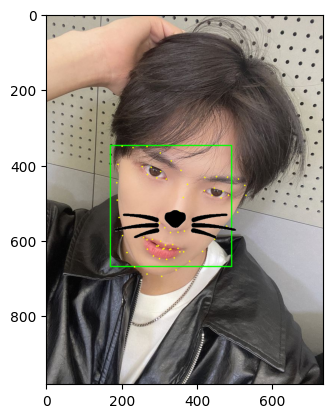

In [27]:
# 1. 스티커 영역 추출 (배경 이미지의 일부)
sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]

# 2. 채널 분리
# img_sticker는 (H, W, 4) -> B, G, R, A
img_sticker_rgb = img_sticker[:, :, :3]  # 앞의 3개 채널 (색상)
alpha_mask = img_sticker[:, :, 3]         # 마지막 4번째 채널 (투명도)

# 3. 마스크를 3차원으로 확장 (H, W) -> (H, W, 1)
# 이렇게 해야 (H, W, 3)인 이미지들과 계산이 가능해집니다.
alpha_mask_3ch = cv2.cvtColor(alpha_mask, cv2.COLOR_GRAY2BGR)

# 4. 투명도 채널을 기준으로 합성
# alpha_mask_3ch가 0보다 큰 곳(불투명)은 스티커 색상을, 0인 곳(투명)은 배경을 사용
img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(alpha_mask_3ch > 0, img_sticker_rgb, sticker_area).astype(np.uint8)

# 결과 확인
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

### 5) 스티커 기울이기 계산 코드 실행

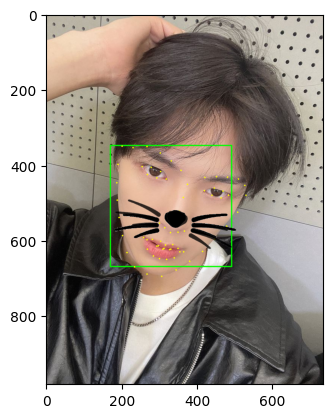

In [29]:
# 1. 설정값
angle = - angle  # 눈썹 사이 기울기
opacity = 0.8  # 투명도 (0.0: 완전 투명, 1.0: 완전 불투명)

# 2. 스티커 읽기 (4채널) 및 크기 조절
img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)
img_sticker = cv2.resize(img_sticker, (w, h))

# 3. 이미지 회전 처리
(h_s, w_s) = img_sticker.shape[:2]
center = (w_s // 2, h_s // 2)

# 회전 행렬 생성 (중심점, 각도, 배율)
# OpenCV는 반시계 방향이 (+)이므로, 시계 방향 회전이 필요하면 -angle을 사용하세요.
matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
img_sticker = cv2.warpAffine(img_sticker, matrix, (w_s, h_s), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0,0))

# 4. 채널 분리 및 투명도 적용
img_sticker_rgb = img_sticker[:, :, :3].astype(float)
alpha_mask = img_sticker[:, :, 3].astype(float) / 255.0  # 0~1 사이로 정규화

# 사용자 설정 투명도 반영
alpha_mask = alpha_mask * opacity

# 5. 배경 영역(sticker_area) 추출
sticker_area = img_show[refined_y:refined_y+h_s, refined_x:refined_x+w_s].astype(float)

# 6. 알파 블렌딩 공식 적용 (부드러운 합성)
# 합성 공식: (스티커 * 알파) + (배경 * (1 - 알파))
for c in range(3): # B, G, R 각 채널에 대해 계산
    sticker_area[:, :, c] = (alpha_mask * img_sticker_rgb[:, :, c] +
                             (1 - alpha_mask) * sticker_area[:, :, c])

# 7. 원본 이미지에 덮어쓰기 (정수형 변환)
img_show[refined_y:refined_y+h_s, refined_x:refined_x+w_s] = sticker_area.astype(np.uint8)

# 결과 출력
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

### 6) 다시 출력하기

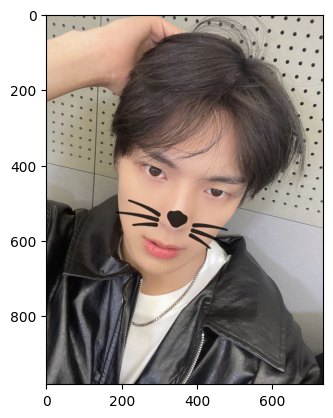

In [30]:
# 위에서 설명했으므로 생략
sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# 합성 공식: (스티커 * 알파) + (배경 * (1 - 알파))
for c in range(3): # B, G, R 각 채널에 대해 계산
    sticker_area[:, :, c] = (alpha_mask * img_sticker_rgb[:, :, c] +
                             (1 - alpha_mask) * sticker_area[:, :, c])

# 원본 이미지에 덮어쓰기 (정수형 변환)
img_bgr[refined_y:refined_y+h_s, refined_x:refined_x+w_s] = sticker_area.astype(np.uint8)

# 결과 출력
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

# 최종 코드 정리

## Step1. 스티커 구하기, 만들기

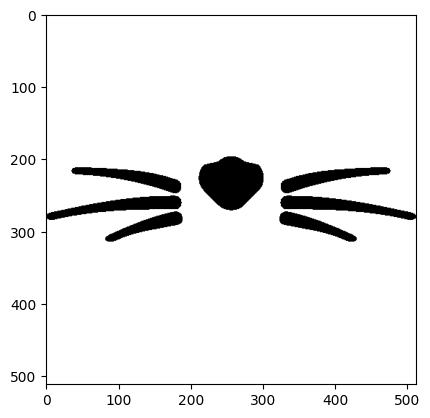

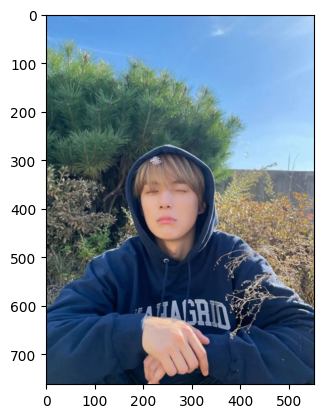

In [31]:
home_dir = os.getenv('HOME')

# 사용할 이미지 불러오기
photo_path = os.path.join(mainpth, 'camera_sticker/images/image_3.jpg') # 본인 이미지가 있는 경로를 가지고 온다.
sticker_path = os.path.join(mainpth, 'camera_sticker/images/cat-whiskers.png') # 고양이 수염 이미지
# OpenCV로 이미지 불러오기 // cv2.imread(이미지 경로) → image객체 행렬을 반환
img_bgr = cv2.imread(photo_path)
img_sticker = cv2.imread(sticker_path)

# 이미지 출력해서 확인해보기 - 스티커
sticker_show = img_sticker.copy()      # 출력용 이미지를 따로 보관합니다
sticker_rgb = cv2.cvtColor(img_sticker, cv2.COLOR_BGR2RGB) #  RGB 이미지로 바꾸기.
plt.imshow(sticker_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

# 이미지 출력해서 확인해보기 - 사진
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) #  RGB 이미지로 바꾸기.
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

## Step 2. 얼굴 검출 & 랜드마크 검출 하기

#### 1) 얼굴 검출

rectangles[[(182, 325) (311, 454)]]


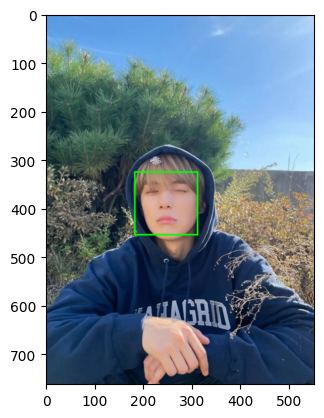

In [32]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)

print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

#### 2) landmark

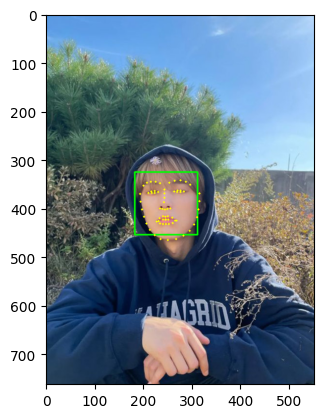

In [33]:
# 저장한 landmark 모델의 주소를 model_path 변수에 저장
model_path = os.path.join(mainpth, 'camera_sticker/models/shape_predictor_68_face_landmarks.dat')
# dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
landmark_predictor = dlib.shape_predictor(model_path)

# 랜드마크의 위치를 저장할 list 생성
list_landmarks = []

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

# face landmark 출력
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)
img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

## Step 3. 스티커 적용 위치 확인하기

### 1) 스티커 위치와 크기 조저을 위한 계산에 필요한 수치 확인

In [34]:
for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    # 수염 붙일 위치와 각도를 계산하기 위해 눈썹 점 위치 불러옴
    print (f"콧등: {landmark[30]}")
    print (f"눈썹 우측: {landmark[21]}")
    print (f"눈썹 좌측: {landmark[22]}")
    x = landmark[30][0]
    y = landmark[30][1]
    x1 = landmark[21][0]
    y1 = landmark[21][1]
    x2 = landmark[22][0]
    y2 = landmark[22][1]
    w = h = dlib_rect.width()
    print (f'(x,y) : ({x},{y})')
    print (f'(x1,y1) : ({x1},{y1})')
    print (f'(x2,y2) : ({x2},{y2})')
    print (f'(w,h) : ({w},{h})')

콧등: (242, 387)
눈썹 우측: (234, 348)
눈썹 좌측: (253, 347)
(x,y) : (242,387)
(x1,y1) : (234,348)
(x2,y2) : (253,347)
(w,h) : (130,130)


### 2) 스티커 크기조정

In [35]:
sticker_path = os.path.join(mainpth, 'camera_sticker/images/cat-whiskers.png') # 고양이 수염 이미지
img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)
img_sticker = cv2.resize(img_sticker, (w,h)) # 스티커 이미지 조정 → w,h는 얼굴 영역의 가로를 차지하는 픽셀의 수(187) // cv2.resize(image객체 행렬, (가로 길이, 세로 길이))
print (img_sticker.shape)

(130, 130, 4)


### 3) 원본에 스티커 이미지를 추가하기 위해 x,y 좌표 계산 및 이미지 자르기


In [36]:
refined_x = x - w // 2
refined_y = y - h // 2 # 고양이 스티커 모양이 위아래 여백이 있기에 가만하여 스티커 높이의 1/2보다 높은 지점부터 붙여야함.
# 음수 발생시 예외 처리
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :] # refined_y가 -98이므로, img_sticker[98: , :]가 된다. (187, 187, 3)에서 (89, 187, 3)이 됨 (187개 중에서 98개가 잘려나감)
    refined_y = 0
print (f'(x,y) : ({refined_x},{refined_y})')

(x,y) : (177,322)


### 4) 스키터 기울이고 반투명하게 하기

In [37]:
import math

def get_slope_and_angle(p1, p2):
    # p1 = (x1, y1), p2 = (x2, y2)
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    # 1. 기울기 구하기 (ZeroDivisionError 방지)
    if dx == 0:
        slope = float('inf')  # 수직선인 경우 무한대
    else:
        slope = dy / dx

    # 2. 각도 구하기 (Radian -> Degree)
    # math.atan2는 (y, x) 순서로 인자를 받습니다.
    radian = math.atan2(dy, dx)
    degree = math.degrees(radian)

    return slope, degree

# 눈썹각도 계산
point_a = (x1, y1)
point_b = (x2, y2)

slope, angle = get_slope_and_angle(point_a, point_b)

print(f"두 점 사이의 기울기: {slope:.2f}")
print(f"두 점 사이의 각도(도): {angle:.2f}°")

두 점 사이의 기울기: -0.05
두 점 사이의 각도(도): -3.01°


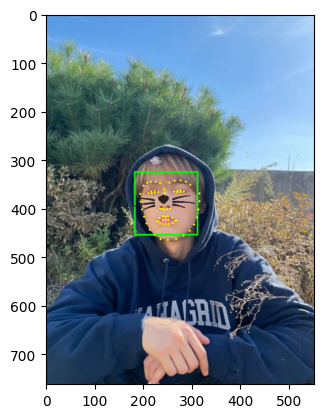

In [38]:
# 1. 설정값
angle = - angle  # 눈썹 사이 기울기
opacity = 0.8  # 투명도 (0.0: 완전 투명, 1.0: 완전 불투명)

# 2. 스티커 읽기 (4채널) 및 크기 조절
img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)
img_sticker = cv2.resize(img_sticker, (w, h))

# 3. 이미지 회전 처리
(h_s, w_s) = img_sticker.shape[:2]
center = (w_s // 2, h_s // 2)

# 회전 행렬 생성 (중심점, 각도, 배율)
# OpenCV는 반시계 방향이 (+)이므로, 시계 방향 회전이 필요하면 -angle을 사용하세요.
matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
img_sticker = cv2.warpAffine(img_sticker, matrix, (w_s, h_s), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0,0))

# 4. 채널 분리 및 투명도 적용
img_sticker_rgb = img_sticker[:, :, :3].astype(float)
alpha_mask = img_sticker[:, :, 3].astype(float) / 255.0  # 0~1 사이로 정규화

# 사용자 설정 투명도 반영
alpha_mask = alpha_mask * opacity

# 5. 배경 영역(sticker_area) 추출
sticker_area = img_show[refined_y:refined_y+h_s, refined_x:refined_x+w_s].astype(float)

# 6. 알파 블렌딩 공식 적용 (부드러운 합성)
# 합성 공식: (스티커 * 알파) + (배경 * (1 - 알파))
for c in range(3): # B, G, R 각 채널에 대해 계산
    sticker_area[:, :, c] = (alpha_mask * img_sticker_rgb[:, :, c] +
                             (1 - alpha_mask) * sticker_area[:, :, c])

# 7. 원본 이미지에 덮어쓰기 (정수형 변환)
img_show[refined_y:refined_y+h_s, refined_x:refined_x+w_s] = sticker_area.astype(np.uint8)

# 결과 출력
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

### 5) 다시출력하기

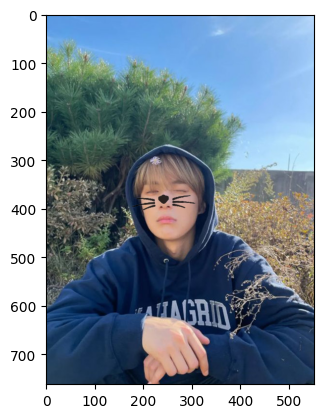

In [39]:
# 위에서 설명했으므로 생략
sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# 합성 공식: (스티커 * 알파) + (배경 * (1 - 알파))
for c in range(3): # B, G, R 각 채널에 대해 계산
    sticker_area[:, :, c] = (alpha_mask * img_sticker_rgb[:, :, c] +
                             (1 - alpha_mask) * sticker_area[:, :, c])

# 원본 이미지에 덮어쓰기 (정수형 변환)
img_bgr[refined_y:refined_y+h_s, refined_x:refined_x+w_s] = sticker_area.astype(np.uint8)

# 결과 출력
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()